<a href="https://colab.research.google.com/github/Penguinboy1990/Machine-Learning/blob/main/Midterm/air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Proof of Billing
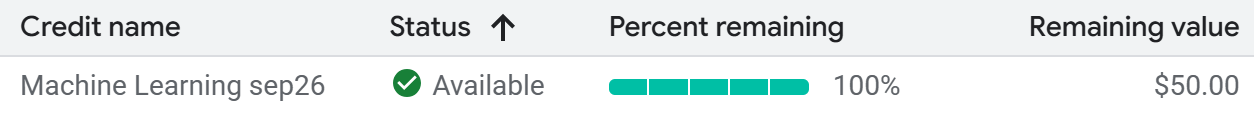

Task 2: Load the dataset into a Pandas DataFrame using the official ucimlrepo package or direct data retrieval methods linked to the UCI repository

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('/AirQualityUCIBetter.csv')

Task 3: Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and examine feature distributions across sensor and meteorological variables.

In [ ]:
print("\nHead Method: ")
print(df.head())

print("\nInfo Method: ")
print(df.info())

print("\nDescribe Method: ")
print(df.describe())


Head Method: 
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6       1360.0     150.0      11.9   
1  3/10/2004  19:00:00     2.0       1292.0     112.0       9.4   
2  3/10/2004  20:00:00     2.2       1402.0      88.0       9.0   
3  3/10/2004  21:00:00     2.2       1376.0      80.0       9.2   
4  3/10/2004  22:00:00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN          NaN  
1  13.3

Task 4: Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer

In [ ]:
print("\nMissing values before pipeline execution.")
print(df.isnull().sum())


Missing values before pipeline execution.
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


In [ ]:
import numpy as np
# Drop empty trailing columns/rows that come from the trailing semicolons
df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")

# Replace sentinel with NaN. Because there's a lot of them, mostly in NMHC(GT)
df_clean = df.replace(-200, np.nan)

# How much is missing per column
missing_report = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print(missing_report.round(2))

NMHC(GT)         90.23
CO(GT)           17.99
NO2(GT)          17.55
NOx(GT)          17.52
PT08.S2(NMHC)     3.91
C6H6(GT)          3.91
PT08.S1(CO)       3.91
PT08.S5(O3)       3.91
T                 3.91
PT08.S3(NOx)      3.91
PT08.S4(NO2)      3.91
RH                3.91
AH                3.91
Date              0.00
Time              0.00
dtype: float64


In [ ]:
# remove NMHC(GT) because it is 90.23% null
df_clean = df_clean.drop(columns=["NMHC(GT)"])

# How much is missing per column
missing_report = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print(missing_report.round(2))

CO(GT)           17.99
NO2(GT)          17.55
NOx(GT)          17.52
PT08.S2(NMHC)     3.91
C6H6(GT)          3.91
PT08.S1(CO)       3.91
PT08.S5(O3)       3.91
T                 3.91
PT08.S3(NOx)      3.91
PT08.S4(NO2)      3.91
RH                3.91
AH                3.91
Date              0.00
Time              0.00
dtype: float64


In [ ]:
# Imputation with SimpleImputer
from sklearn.impute import SimpleImputer
numeric_cols = df_clean.select_dtypes(include=np.number).columns
numeric_imputer = SimpleImputer(strategy="median")
df_clean[numeric_cols] = numeric_imputer.fit_transform(df_clean[numeric_cols])

categorical_cols = df_clean.select_dtypes(exclude=np.number).columns
categorical_imputer = SimpleImputer(strategy="most_frequent")

df_clean[categorical_cols] = categorical_imputer.fit_transform(df_clean[categorical_cols])

print("Missing values after imputation:")
missing_report = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print(missing_report.round(2))

Missing values after imputation:
Date             0.0
Time             0.0
CO(GT)           0.0
PT08.S1(CO)      0.0
C6H6(GT)         0.0
PT08.S2(NMHC)    0.0
NOx(GT)          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
PT08.S5(O3)      0.0
T                0.0
RH               0.0
AH               0.0
dtype: float64


Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = df_clean.select_dtypes(include=np.number).columns.tolist()

categorical_features = df_clean.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
numeric_pipeline = Pipeline(steps=[("scaler", StandardScaler())])

categorical_pipeline = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_pipeline, numeric_features),("cat", categorical_pipeline, categorical_features)])

full_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

df_processed = full_pipeline.fit_transform(df_clean)

df_processed = pd.DataFrame.sparse.from_spmatrix(df_processed, index=df_clean.index, columns=preprocessor.get_feature_names_out())

Task 6: Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance.

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score

# CO concentration separated into 3 categorical classes
y = pd.qcut(df_clean["CO(GT)"], q=3, labels=["Low", "Moderate", "High"])
X = df_processed.drop(columns=["num__CO(GT)", "Date", "date__Date"], errors="ignore")
valid = y.notna()
X, y = X.loc[valid], y.loc[valid]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SGD Log Loss": SGDClassifier(loss="log_loss", alpha=0.0001, max_iter=2000, random_state=35),
    "SGD Modified Huber": SGDClassifier(loss="modified_huber", alpha=0.001, max_iter=2000, random_state=35)}

results = []

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    predictions = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions, average="weighted"),
        "Training Time (s)": round(elapsed, 4),
        "Iterations": model.n_iter_})

print(pd.DataFrame(results).to_string(index=False))

              Model  Accuracy  F1 Score  Training Time (s) Iterations
Logistic Regression  0.854167  0.852726             0.4131      [112]
       SGD Log Loss  0.829594  0.825425             0.1313         38
 SGD Modified Huber  0.831197  0.826296             0.0911         44


Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

y = df_clean["CO(GT)"]
X = df_processed.drop(columns=["num__CO(GT)", "Date", "date__Date"], errors="ignore")

valid = y.notna()
X, y = X.loc[valid], y.loc[valid]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=0.1)": Ridge(alpha=0.1),
    "Ridge (alpha=1)": Ridge(alpha=1),
    "Ridge (alpha=10)": Ridge(alpha=10),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01, max_iter=10000),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1, max_iter=10000),
    "Lasso (alpha=1)": Lasso(alpha=1, max_iter=10000)}

results = []
coefficients = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    predictions = model.predict(X_test)
    results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, predictions),
        "R²": r2_score(y_test, predictions),
        "Training Time (s)": round(elapsed, 4),
        "Nonzero Coefficients": (model.coef_ != 0).sum()})

    coefficients[name] = pd.Series(model.coef_, index=X_train.columns)

print(pd.DataFrame(results).to_string(index=False))
coefficient_comparison = pd.DataFrame(coefficients)
print("\nCoefficients:")
print(coefficient_comparison.round(4).to_string())

             Model      MSE       R²  Training Time (s)  Nonzero Coefficients
 Linear Regression 0.223449 0.875471             0.0559                   426
 Ridge (alpha=0.1) 0.223344 0.875530             0.0287                   426
   Ridge (alpha=1) 0.222661 0.875910             0.0308                   426
  Ridge (alpha=10) 0.229490 0.872105             0.0238                   426
Lasso (alpha=0.01) 0.324759 0.819011             0.4908                    15
 Lasso (alpha=0.1) 0.379730 0.788375             0.2104                     5
   Lasso (alpha=1) 1.659217 0.075314             0.0332                     1

Coefficients:
                      Linear Regression  Ridge (alpha=0.1)  Ridge (alpha=1)  Ridge (alpha=10)  Lasso (alpha=0.01)  Lasso (alpha=0.1)  Lasso (alpha=1)
num__PT08.S1(CO)                 0.1929             0.1710           0.1696            0.1685              0.1247             0.1058           0.0000
num__C6H6(GT)                    0.5837             0.6156   

Task 8: Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.

It was running overnight somehow, even when the tab was closed. Still don't know how to stop it...
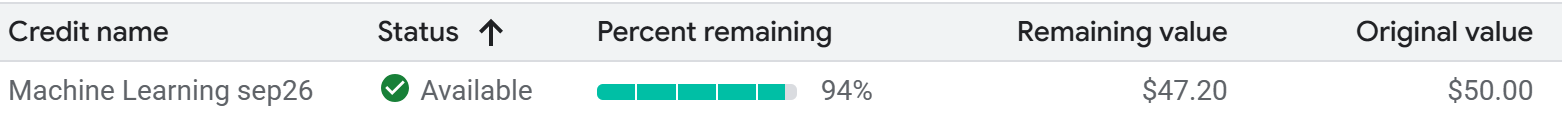

I think I figured it out...
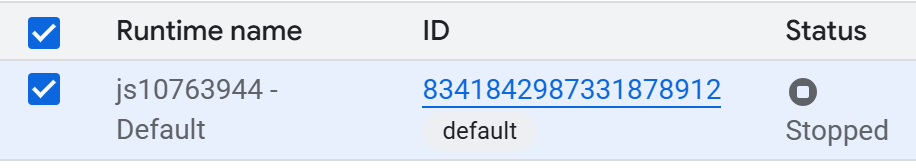